# **Mental Health in Tech Survey**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [ ]:
# Dataset:
# https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey

In [ ]:
survey = pd.read_csv('survey.csv')

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


# Cleaning

In [ ]:
survey = survey.drop(columns=['comments', 'state', 'Timestamp', 'Country'])

In [ ]:
survey['Gender'] = survey['Gender'].str.lower().str.strip()
male = ['m', 'male', 'male-ish', 'maile', 'cis male', 'mal', 'male (cis)', 'make', 'man', 'msle', 'mail', 'cis man', 'malr', 'guy (-ish) ^_^']
female = ['f', 'female', 'cis female', 'woman', 'femail', 'femake', 'cis-female/femme', 'female (cis)']

survey['Gender'] = survey['Gender'].replace(male, 'male')
survey['Gender'] = survey['Gender'].replace(female, 'female')
survey.loc[~survey['Gender'].isin(['male', 'female']), 'Gender'] = 'other'

array(['female', 'male', 'other'], dtype=object)

In [ ]:
survey = survey[(survey['Age'] > 15) & (survey['Age'] < 100)]

In [ ]:
survey['self_employed'] = survey['self_employed'].fillna('No')
survey['work_interfere'] = survey['work_interfere'].fillna('Never')

In [ ]:
yes_no = ['self_employed', 'family_history', 'treatment', 'remote_work', 'tech_company', 'obs_consequence']
survey[yes_no] = survey[yes_no].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_6650/3563037011.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survey[yes_no] = survey[yes_no].replace({'Yes': 1, 'No': 0})


In [ ]:
survey['work_interfere'] = survey['work_interfere'].replace({
    'Never': 0,
    'Rarely': 0.33,
    'Sometimes': 0.66,
    'Often': 1
})

survey['no_employees'] = survey['no_employees'].replace({
    '1-5': 0,
    '6-25': 0.2,
    '26-100': 0.4,
    '100-500': 0.6,
    '500-1000': 0.8,
    'More than 1000': 1
})

survey['leave'] = survey['leave'].replace({
    'Very easy': 0,
    'Somewhat easy': 0.25,
    "Don't know": 0.5,
    'Somewhat difficult': 0.75,
    'Very difficult': 1
})

/tmp/ipykernel_6650/3017078917.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survey['work_interfere'] = survey['work_interfere'].replace({
/tmp/ipykernel_6650/3017078917.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survey['no_employees'] = survey['no_employees'].replace({
/tmp/ipykernel_6650/3017078917.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future beha

In [ ]:
nominal_cols = ['Gender', 'benefits', 'care_options', 'wellness_program', 'seek_help',
                'anonymity', 'mental_health_consequence', 'phys_health_consequence',
                'coworkers', 'supervisor', 'mental_health_interview',
                'phys_health_interview', 'mental_vs_physical']

# Visualisations

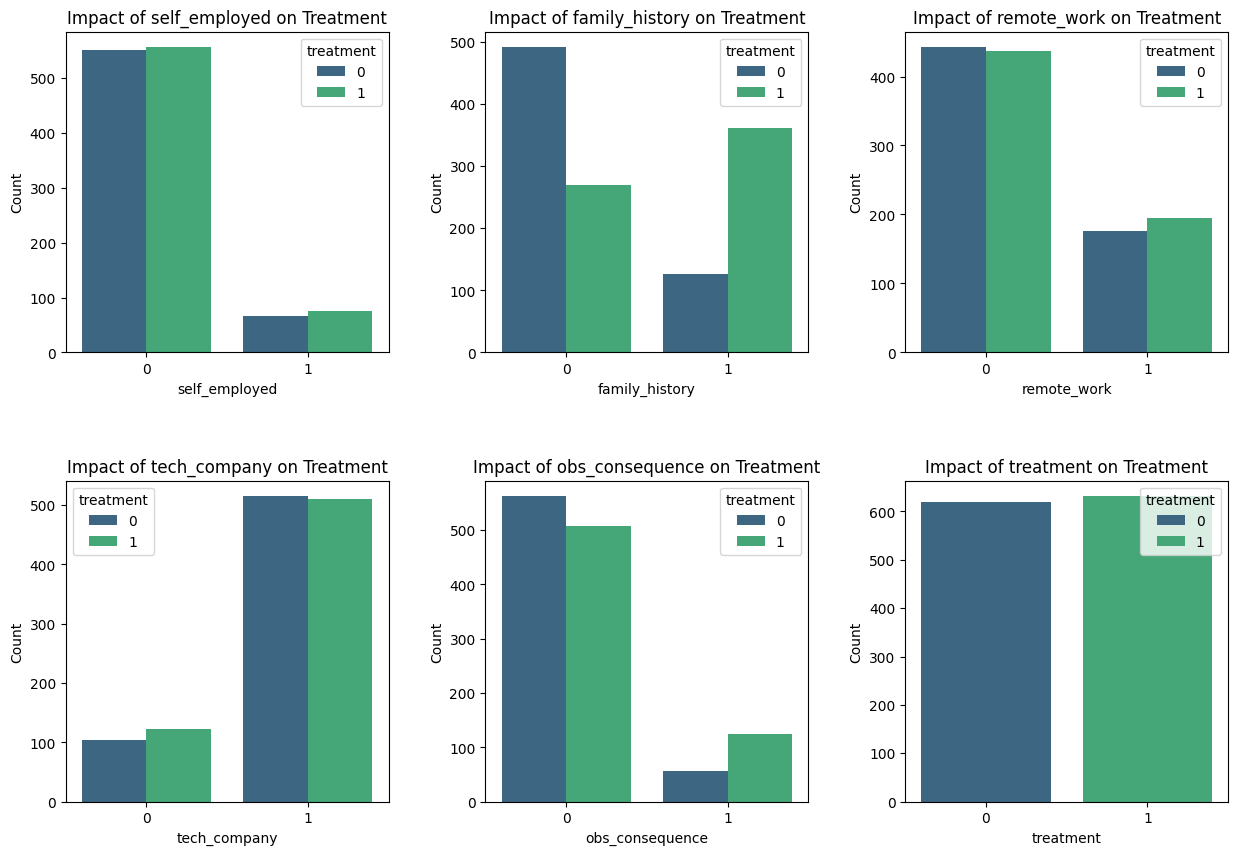

In [ ]:
binary = ['self_employed', 'family_history', 'remote_work', 'tech_company', 'obs_consequence', 'treatment']

plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, col in enumerate(binary):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=col, hue='treatment', data=survey, palette='viridis')
    plt.title(f'Impact of {col} on Treatment')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.show()

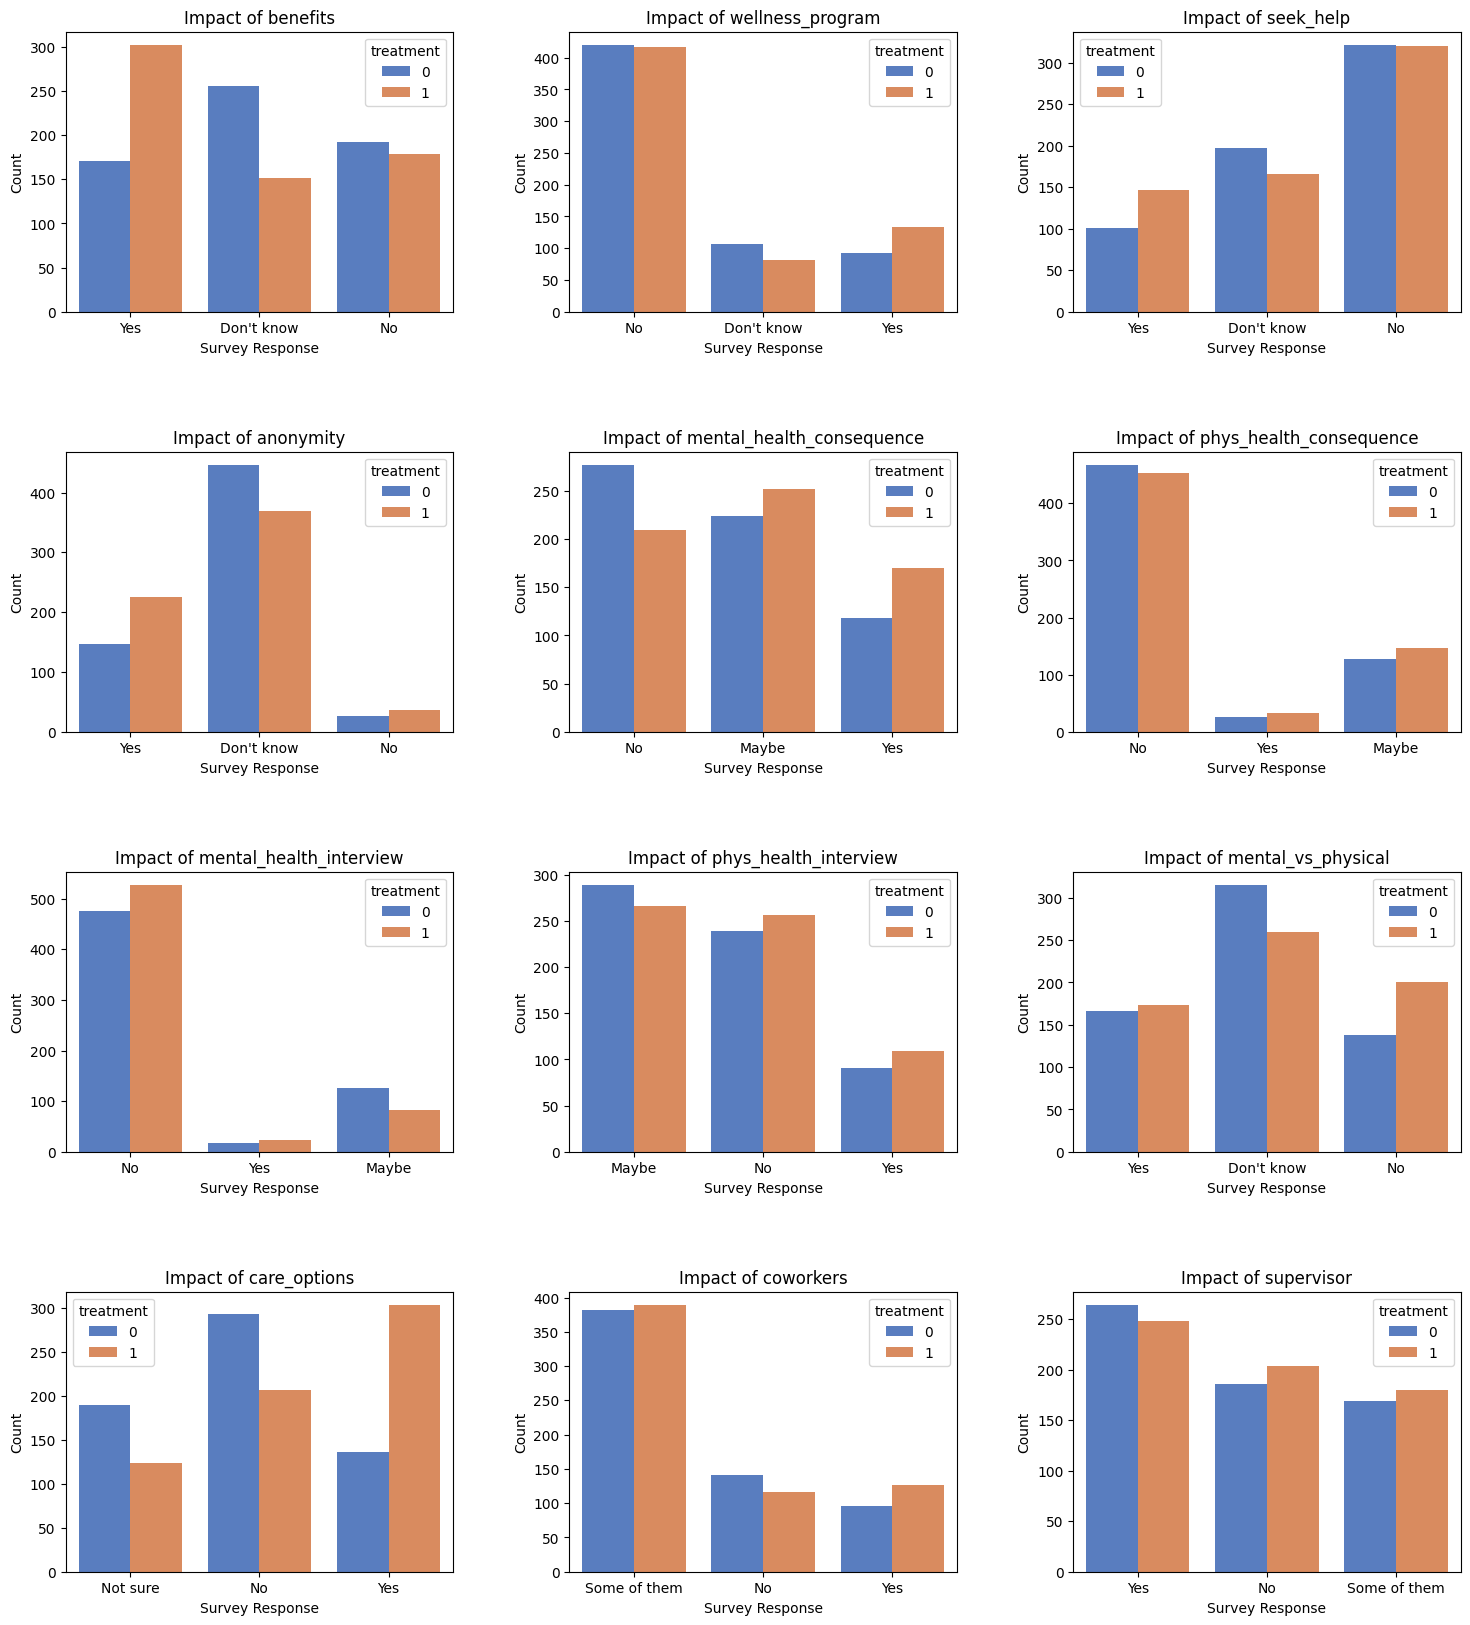

In [ ]:
survey_categorical_features = [
    'benefits', 'wellness_program', 'seek_help', 'anonymity',
    'mental_health_consequence', 'phys_health_consequence',
    'mental_health_interview', 'phys_health_interview', 'mental_vs_physical',
    'care_options', 'coworkers', 'supervisor'
]

plt.figure(figsize=(18, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, col in enumerate(survey_categorical_features):
    plt.subplot(4, 3, i+1)
    sns.countplot(x=col, hue='treatment', data=survey, palette='muted')
    plt.title(f'Impact of {col}')
    plt.xlabel('Survey Response')
    plt.ylabel('Count')

plt.show()

# Data preparation

In [ ]:
survey = pd.get_dummies(survey, columns=nominal_cols, drop_first=True)

In [ ]:
X = survey.drop(columns=['treatment'])
y = survey['treatment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = MinMaxScaler()
X_train[['Age']] = scaler.fit_transform(X_train[['Age']])
X_test[['Age']] = scaler.transform(X_test[['Age']])

# Functions

In [ ]:
def print_model_reports(model_name, scores_cv, y_true, y_pred):
    print(f"=== {model_name.upper()} ===")

    if scores_cv is not None:
        print("--- Cross-Validation Results (Mean 5-Fold CV on X_train) ---")
        print(f"Accuracy:  {scores_cv['test_accuracy'].mean():.4f}")
        print(f"Precision: {scores_cv['test_precision'].mean():.4f}")
        print(f"Recall:    {scores_cv['test_recall'].mean():.4f}")
        print(f"F1-Score:  {scores_cv['test_f1'].mean():.4f}")
        print("\n")

    print("--- Final Test (on holdout test set) ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")

In [ ]:
def plot_custom_confusion_matrix(y_true, y_pred, title, cmap='Blues'):

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Treatment', 'Treatment'])

    plt.figure(figsize=(6, 5))
    disp.plot(cmap=cmap, ax=plt.gca())
    plt.title(title, fontsize=11, pad=10)
    plt.tight_layout()
    plt.show()

# Optimal Logistic Regression Model

In [ ]:
lr_base = LogisticRegression(
    penalty=None,
    max_iter=10000
)

selector = RFECV(
    lr_base,
    step=1,
    min_features_to_select=1,
    cv=5,
    scoring="f1"
)

selector.fit(X_train, y_train)

RFECV(cv=5, estimator=LogisticRegression(max_iter=10000, penalty=None),
      scoring='f1')

In [ ]:
feature_names = X_train.columns[selector.support_]
X_train_selected = X_train[feature_names]
X_test_selected = X_test[feature_names]

In [ ]:
selected_features_df = pd.DataFrame({
    "selected": selector.support_,
    "ranking": selector.ranking_
}, index=X_train.columns)

In [ ]:
X_train_selected = X_train[feature_names]
X_test_selected = X_test[feature_names]

In [ ]:
scores_selected = cross_validate(
    lr_base,
    X_train_selected,
    y_train,
    cv=5,
    scoring=("accuracy", "precision", "recall", "f1")
)

In [ ]:
lr_selected = LogisticRegression(penalty=None, max_iter=10000)
lr_selected.fit(X_train_selected, y_train)
y_pred_lr = lr_selected.predict(X_test_selected)

=== OPTIMAL LOGISTIC REGRESSION ===
--- Cross-Validation Results (Mean 5-Fold CV on X_train) ---
Accuracy:  0.8150
Precision: 0.7986
Recall:    0.8495
F1-Score:  0.8230


--- Final Test (on holdout test set) ---
Accuracy:  0.7968
Precision: 0.7969
Recall:    0.8031
F1-Score:  0.8000


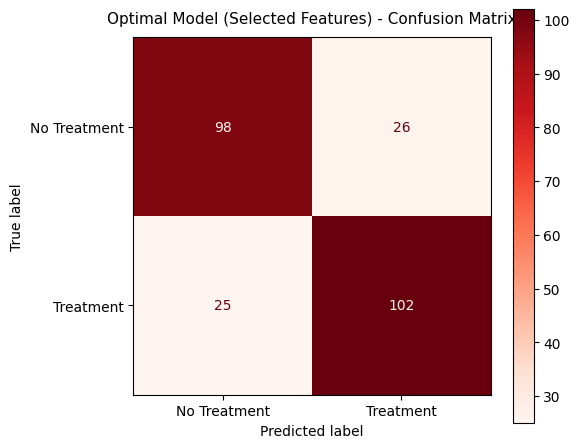

In [ ]:
print_model_reports("Optimal Logistic Regression", scores_selected, y_test, y_pred_lr)
plot_custom_confusion_matrix(y_test, y_pred_lr, "Optimal Model (Selected Features) - Confusion Matrix", cmap='Reds')

# Support Vector Machine with RBF Kernel

In [ ]:
svm_rbf = SVC(kernel='rbf', random_state=42)
scores_rbf = cross_validate(svm_rbf, X_train, y_train, cv=5, scoring=("accuracy", "precision", "recall", "f1"))

svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

=== SVM: RBF KERNEL ===
--- Cross-Validation Results (Mean 5-Fold CV on X_train) ---
Accuracy:  0.8110
Precision: 0.7815
Recall:    0.8693
F1-Score:  0.8226


--- Final Test (on holdout test set) ---
Accuracy:  0.8247
Precision: 0.8168
Recall:    0.8425
F1-Score:  0.8295


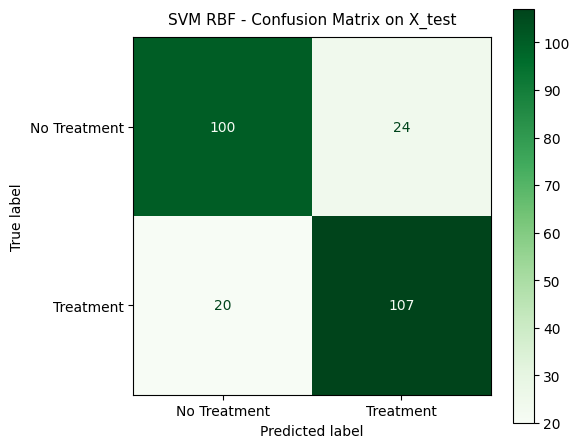

In [ ]:
print_model_reports("SVM: RBF Kernel", scores_rbf, y_test, y_pred_rbf)
plot_custom_confusion_matrix(y_test, y_pred_rbf, "SVM RBF - Confusion Matrix on X_test", cmap='Greens')

# Neural Network Model

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(10, 5), activation='tanh', solver='adam', learning_rate_init=0.001, max_iter=500, random_state=0)
scores_mlp = cross_validate(mlp, X_train, y_train, cv=5, scoring=("accuracy", "precision", "recall", "f1"))

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

=== MULTILAYER PERCEPTRON (MLP) ===
--- Cross-Validation Results (Mean 5-Fold CV on X_train) ---
Accuracy:  0.7820
Precision: 0.7705
Recall:    0.8099
F1-Score:  0.7892


--- Final Test (on holdout test set) ---
Accuracy:  0.8446
Precision: 0.8284
Recall:    0.8740
F1-Score:  0.8506


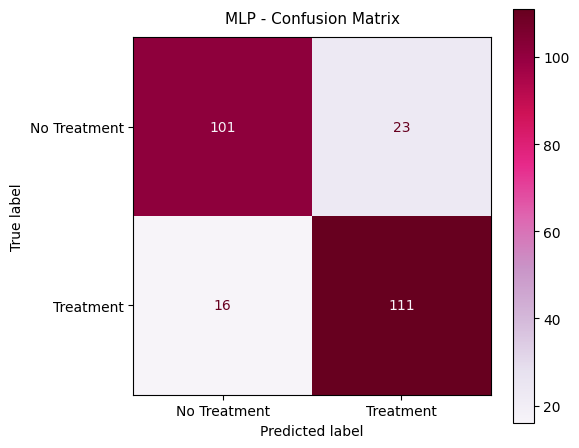

In [ ]:
print_model_reports("Multilayer Perceptron (MLP)", scores_mlp, y_test, y_pred_mlp)
plot_custom_confusion_matrix(y_test, y_pred_mlp, "MLP - Confusion Matrix", cmap='PuRd')

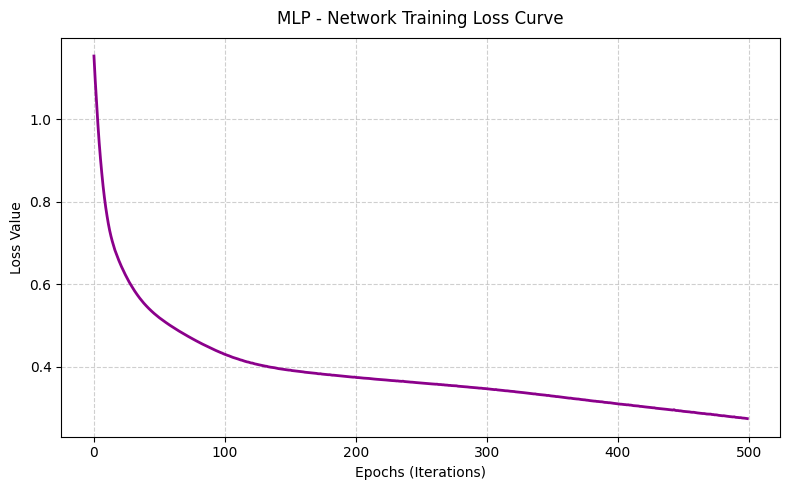

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='darkmagenta', linewidth=2)
plt.title("MLP - Network Training Loss Curve", fontsize=12, pad=10)
plt.xlabel("Epochs (Iterations)", fontsize=10)
plt.ylabel("Loss Value", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression (RFECV)",
        "SVM (RBF Kernel)",
        "Multilayer Perceptron (MLP)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rbf),
        precision_score(y_test, y_pred_mlp)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rbf),
        recall_score(y_test, y_pred_mlp)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rbf),
        f1_score(y_test, y_pred_mlp)
    ]
})

print("\nModel Performance Comparison Table on Test Set:")
print(results)


Model Performance Comparison Table on Test Set:
                         Model  Accuracy  Precision    Recall        F1
0  Logistic Regression (RFECV)  0.796813   0.796875  0.803150  0.800000
1             SVM (RBF Kernel)  0.824701   0.816794  0.842520  0.829457
2  Multilayer Perceptron (MLP)  0.844622   0.828358  0.874016  0.850575


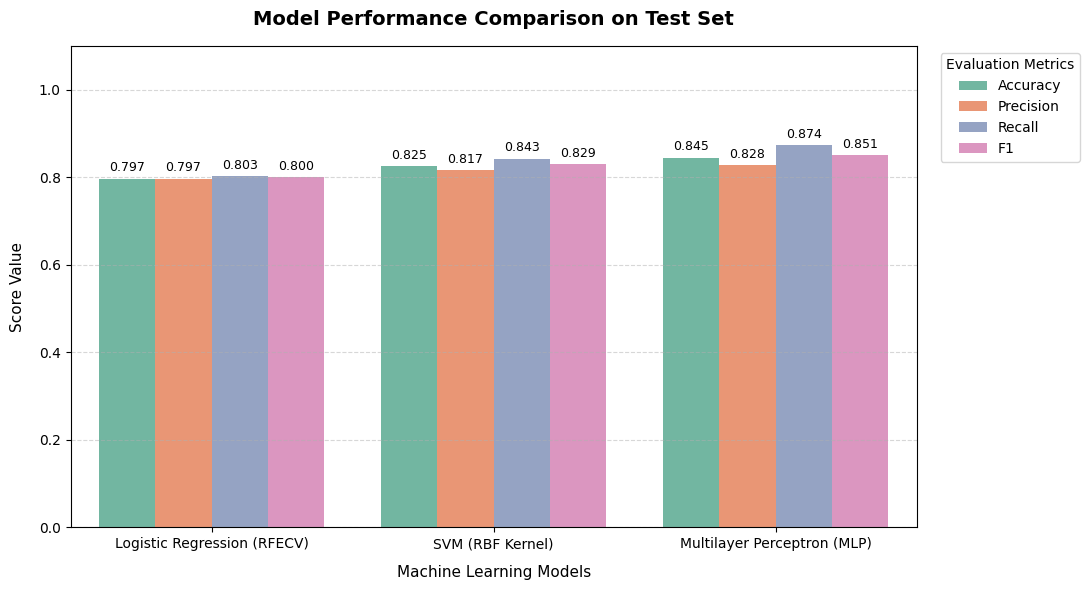

In [233]:
results_melted = pd.melt(
    results,
    id_vars=["Model"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    data=results_melted,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Model Performance Comparison on Test Set", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Machine Learning Models", fontsize=11, labelpad=10)
plt.ylabel("Score Value", fontsize=11, labelpad=10)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Evaluation Metrics", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()